In [23]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import yaml
from pathlib import Path

import EI.ei_original as ut
import EI.ei_open_loop as eol
import EI.ei_unified as eu
import EI.ei_jax as ej

from utils.logger import logger, tqdm_bar
from utils.plotting_utils import plot_phase_diag, plot_energies_uv, plot_nalpha_beta, plot_nalpha_beta_bz

In [24]:
plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Calibri"],
        "font.size": 8,
        "mathtext.fontset": "cm",
    }
)

gnuplot_barve = cm.gnuplot2_r(np.linspace(0.3, 1, 10))
gnuplot_custom = LinearSegmentedColormap.from_list("gnuplot_custom", gnuplot_barve)

brg_barve = cmaps.guppy(np.linspace(0, 1, 10))
bgr_custom = LinearSegmentedColormap.from_list("bgr_custom", brg_barve)

YlGn_barve = cm.YlGn(np.linspace(0, 0.8, 10))
ylgn_custom = LinearSegmentedColormap.from_list("ylgn_custom", YlGn_barve)

markers = ["o", "D", "^", "x", "v", "<", ">", "p", "*", "X"]

set1_list = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#f781bf",
    "#999999",
    "#a65628",
]
bold_list = [
    "#7f3c8d",
    "#11a579",
    "#3969ac",
    "#e73f74",
    "#f2b701",
    "#80ba5a",
    "#e68310",
    "#008695",
    "#cf1c90",
    "#f97b72",
    "#a5aa99",
]

OUT = "/home/kzeleznikar/IJS-F1/Koda/EI_baths/"
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png", dpi=300)


In [25]:
cfg_path = Path("/home/kzeleznikar/IJS-F1/Koda/EI_baths/config/config_test.yaml")

with cfg_path.open("r") as f:
    cfg = yaml.safe_load(f)

md = cfg["model"]
eq = cfg["equilibrium"]
sc = cfg["scan"]
op = cfg["open_system"]

nk = md["nk"]
bp = md["band"]["pars"]

bd = eu.tb_2d(nk["scan"], **bp)
bd_ref = eu.tb_2d(nk["reference"], **bp)

p = eu.MFPars(**md["mean_field"])

In [ ]:
s0 = eu.solve_eq(bd_ref, p, **eq["initial"], **eq["solve"])

d0 = abs(s0.d)
m0 = s0.m
mu0 = s0.mu

# za normalizacijo
tc = eu.critical_temperature(bd_ref, p, **eq["critical"])

logger.info(f"Delta_0 = {d0}")
logger.info(f"m_0     = {m0}")
logger.info(f"mu0     = {mu0}")
logger.info(f"T_c     = {tc}")

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

[14:57:11] [INFO    ] Delta_0 = 0.4277674535851255
[14:57:11] [INFO    ] m_0     = 0.23239325746200892
[14:57:11] [INFO    ] T_c     = 0.23073367729038
[14:57:11] [INFO    ] mu0     = 1.5347833443573202


In [27]:
tg = sc["temperature"]

tn = np.linspace( tg["min_ratio"], tg["max_ratio"], tg["nt"])

t1a = tn * tc
t2a = tn * tc
nt = tg["nt"]

In [28]:
bc = op["bath"]

rf = getattr(ej, bc["rate"])

bpars = dict(bc["pars"])
bpars["rate"] = rf

set mu_B = E_c

In [ ]:
Ec = md["mean_field"]["v"] * md["mean_field"]["n"] /2 + (md["band"]["pars"]["ta"] + md["band"]["pars"]["tb"]) / (2 * (md["band"]["pars"]["ta"] - md["band"]["pars"]["tb"])) * (md["mean_field"]["v"] * s0.m - md["band"]["pars"]["gap"])
logger.info(f"E_c = {Ec}")

bpars["mu"] = Ec

[14:46:30] [INFO    ] 1.1205983143655023


In [30]:
da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)
it = np.zeros((nt, nt), dtype=int)
ok = np.zeros((nt, nt), dtype=bool)

de = s0.d
me = s0.m


for j in tqdm(range(nt), desc="T2"):
    t2 = t2a[j]
    se = eu.solve_eq(bd, p, t=t2,
        d=max(abs(de), 1.0e-6),
        m=me,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    n = se.n.copy()
    d = se.d
    m = se.m

    for i in tqdm(
        range(j, nt),
        desc="T1",
        leave=False,
    ):
        t1 = t1a[i]
        bs = (ej.gam_db(t=t1, name="bath 1", **bpars),
              ej.gam_db(t=t2, name="bath 2", **bpars))

        so = ej.solve_open(bd, p, n, bs, d=d, m=m, **op["solve"])

        ds = 0.1 * d0

        da[j, i] = abs(so.d)
        ma[j, i] = so.m
        er[j, i] = so.err
        it[j, i] = so.it
        ok[j, i] = so.ok

        #update
        n = so.n.copy()
        d = max(abs(so.d), ds)
        m = so.m

        da[i, j] = da[j, i]
        ma[i, j] = ma[j, i]
        er[i, j] = er[j, i]
        it[i, j] = it[j, i]
        ok[i, j] = ok[j, i]

T2: 100%|██████████| 20/20 [00:08<00:00,  2.25it/s]


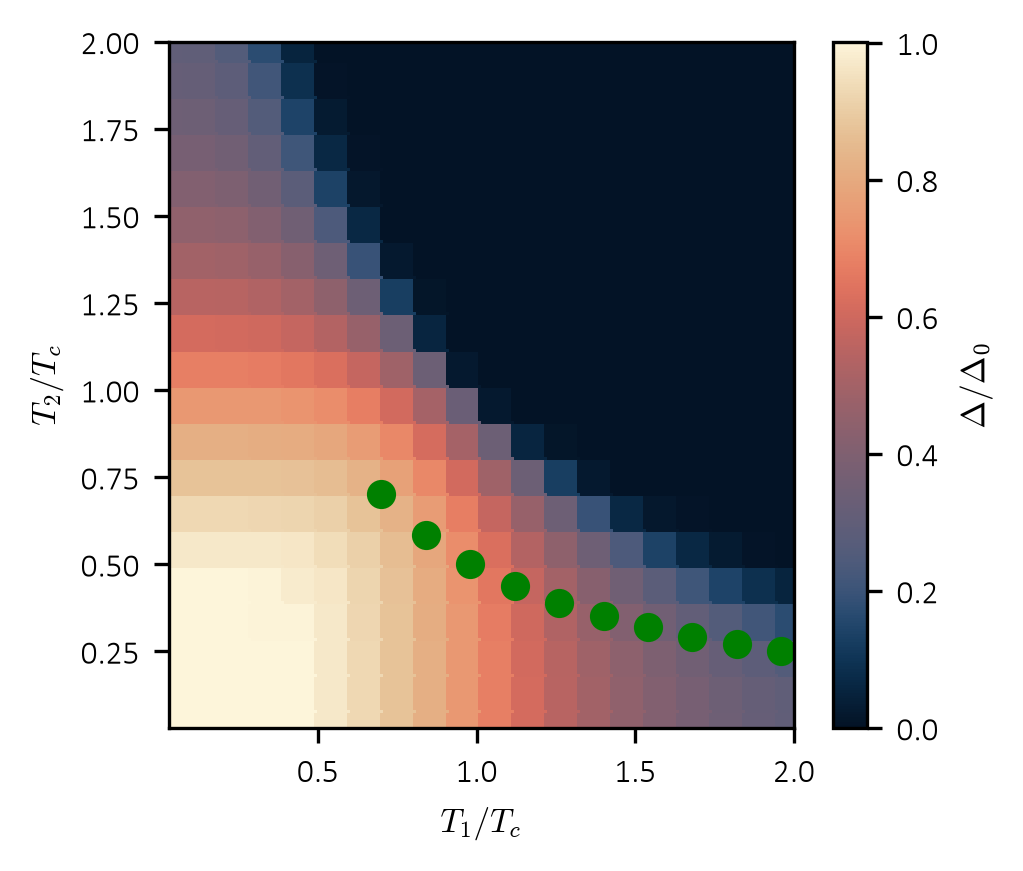

In [31]:
plot_phase_diag(da, d0, tn, config = cfg, OUT=OUT, name="phase_diag_test", save=False)

In [32]:
rs = cfg["ratio_sweep"]

x0 = rs["x0"]
r = np.arange(rs["r_min"], rs["r_max"], rs["r_step"]) ** 2
x1a = x0 * np.sqrt(r)
x2a = x0 / np.sqrt(r)

t0 = x0 * tc

band = getattr(eu, md["band"]["name"])
bd_dense = band(md["nk"]["reference"], **md["band"]["pars"])
p = eu.MFPars(**md["mean_field"])

se = eu.solve_eq(bd_dense, p, t=t0, d=max(abs(s0.d), 1.0e-4), m=s0.m, **eq["solve"])

nk1 = int(round(np.sqrt(se.n.shape[1])))

c = nk1 // 2
q = np.arange(c + 1)

i1 = c - q
j1 = np.full_like(q, c)

i2 = np.zeros(c, dtype=int)
j2 = c - np.arange(1, c + 1)

i3 = np.arange(1, c + 1)
j3 = np.arange(1, c + 1)

ii = np.concatenate((i1, i2, i3))
jj = np.concatenate((j1, j2, j3))

s1 = np.linspace(0.0, np.pi, c + 1)
s2 = np.linspace(np.pi, 2.0 * np.pi, c + 1)[1:]
s3 = np.linspace(2.0 * np.pi, (2.0 + np.sqrt(2.0)) * np.pi, c + 1)[1:]

ks = np.concatenate((s1, s2, s3))

kt = [0.0, np.pi, 2.0 * np.pi, (2.0 + np.sqrt(2.0)) * np.pi]
kl = [r"$\Gamma$", r"$X$", r"$M$", r"$\Gamma$"]


def path(n):
    n = np.asarray(n)
    na = n[0].reshape(nk1, nk1)[ii, jj]
    nb = n[1].reshape(nk1, nk1)[ii, jj]
    return na, nb


def path1(z):
    z = np.asarray(z).reshape(nk1, nk1)
    return z[ii, jj]


nea, neb = path(se.n)

gam_pars = dict(op["bath"]["pars"])
gam_pars["rate"] = getattr(ej, op["bath"]["rate"])

naa = np.empty((x2a.size, ks.size))
nba = np.empty_like(naa)
da1 = np.empty(x2a.size)
era = np.empty(x2a.size)
oka = np.empty(x2a.size, dtype=bool)

eaa = np.empty_like(naa)
eba = np.empty_like(naa)
ua = np.empty_like(naa)
va = np.empty_like(naa)

eah = np.empty_like(naa)
ebh = np.empty_like(naa)

nfa = np.empty((r.size, 2, nk1, nk1))

n = se.n.copy()
d = se.d
m = se.m

bar = tqdm(range(r.size), desc="Ratio sweep")

for q in bar:
    x1 = x1a[q]
    x2 = x2a[q]

    t1 = x1 * tc
    t2 = x2 * tc

    bs = (
        ej.gam_db(t1, name="bath 1", **gam_pars),
        ej.gam_db(t2, name="bath 2", **gam_pars),
    )

    sp = ej.solve_open(bd_dense, p, n, bs, d=d, m=m, **op["solve"])
    
    nfa[q] = np.asarray(sp.n).reshape(2, nk1, nk1)
    naa[q], nba[q] = path(sp.n)
    da1[q] = abs(sp.d)
    era[q] = sp.err
    oka[q] = sp.ok

    eaa[q], eba[q] = path(sp.st.e)
    ua[q] = path1(sp.st.u)
    va[q] = path1(sp.st.v)

    eah[q] = path1(sp.st.eah)
    ebh[q] = path1(sp.st.ebh)

    n = sp.n.copy()
    d = sp.d
    m = sp.m

    bar.set_postfix(r=f"{r[q]:.2f}", t1=f"{x1:.2f}", t2=f"{x2:.2f}", d=f"{abs(sp.d):.3e}", err=f"{sp.err:.2e}")

print("All converged:", np.all(oka))
print("Largest error:", np.max(era))

Ratio sweep: 100%|██████████| 10/10 [00:21<00:00,  2.15s/it, d=3.313e-05, err=2.56e-05, r=7.84, t1=1.96, t2=0.25]

All converged: True
Largest error: 4.714261740446091e-05


Plotting: 100%|██████████| 10/10 [00:00<00:00, 2288.84it/s]
/home/kzeleznikar/IJS-F1/Koda/src/utils/plotting_utils.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


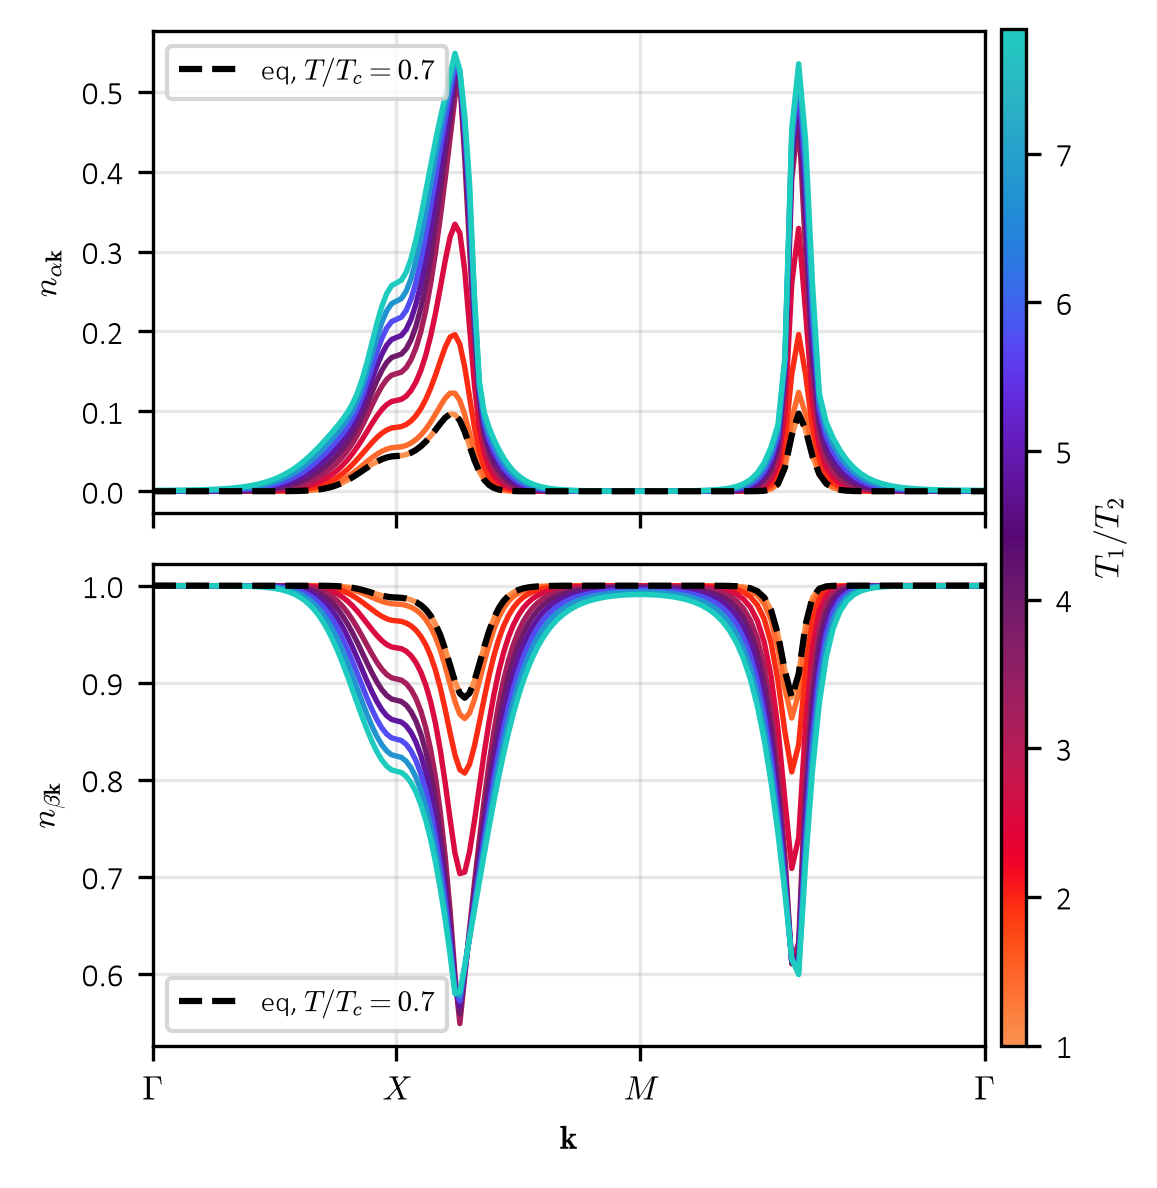

In [33]:
plot_nalpha_beta(naa, nba, nea, neb, r, ks, kt, kl,cfg, OUT=OUT, name="nalpha_beta_test", save=False, overwrite=True)

/home/kzeleznikar/IJS-F1/Koda/src/utils/plotting_utils.py:279: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


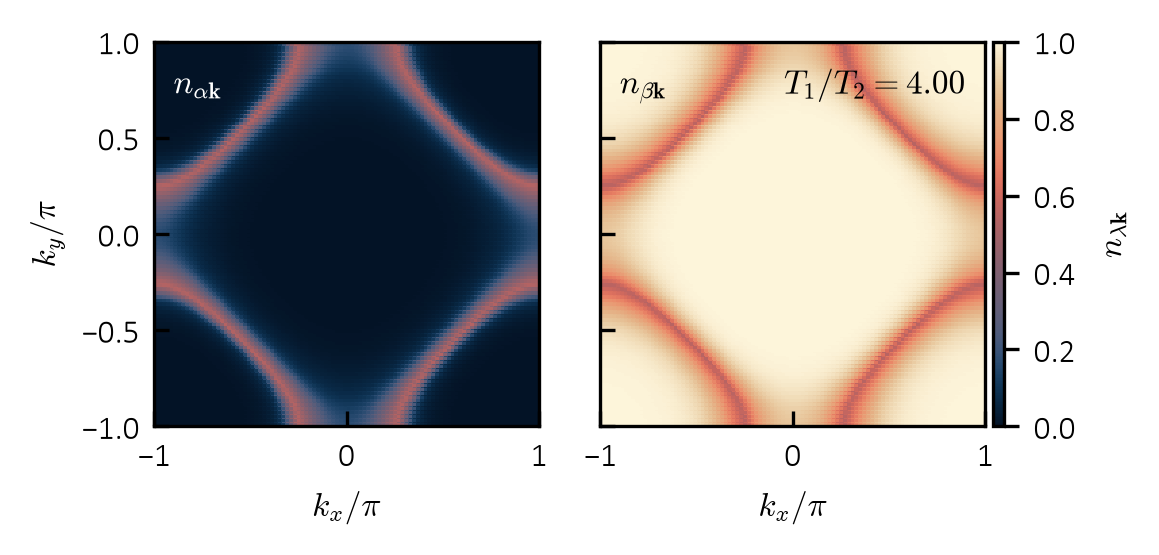

In [34]:
q0 = 5

plot_nalpha_beta_bz(nfa, r, q0, cfg, OUT=OUT, name="nalpha_beta_bz_q3", save=False, overwrite=True)

Plotting: 100%|██████████| 10/10 [00:00<00:00, 1172.74it/s]
/home/kzeleznikar/IJS-F1/Koda/src/utils/plotting_utils.py:395: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


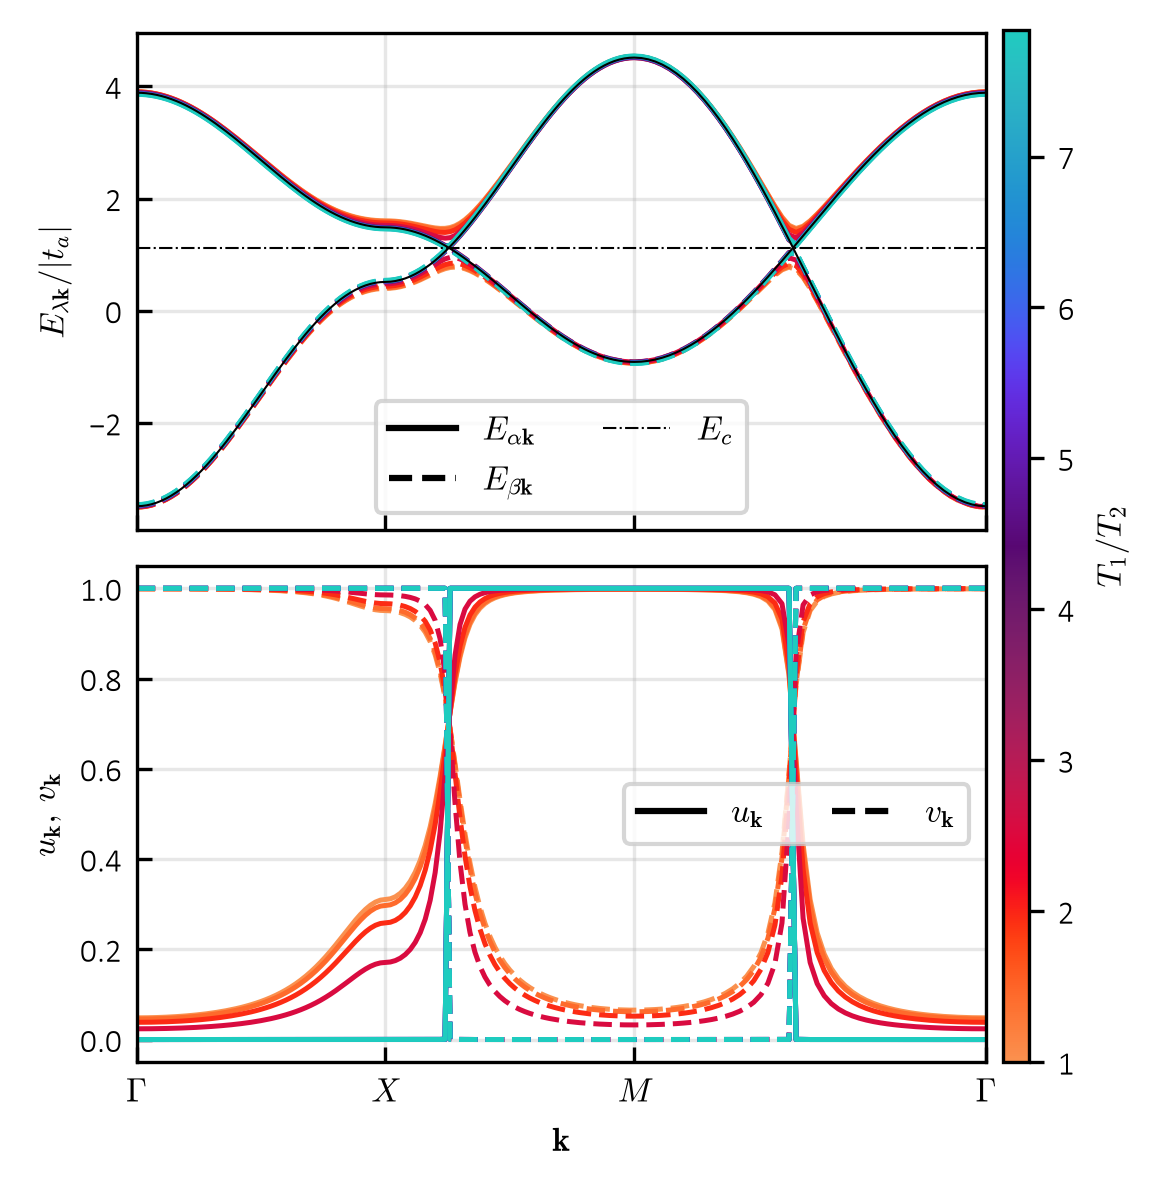

In [35]:
ra = r

plot_energies_uv(eaa, eba, ua, va, eah, ebh, ra, ks, kt, kl, cfg,
                 OUT=OUT, name="energies_uv_b2", save=False, overwrite=True, Ec=Ec)